In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('patientt.csv')


In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

In [7]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Smoking', 'Alcohol Intake', 'Exercise Induced Angina', 'Chest Pain Type', 'Family History', 'Diabetes', 'Obesity']:
    df[col] = le.fit_transform(df[col])


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Blood Sugar', 'Exercise Hours', 'Stress Level']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [10]:
import matplotlib.pyplot as plt

In [11]:
import seaborn as sns

<Axes: xlabel='Heart Disease', ylabel='count'>

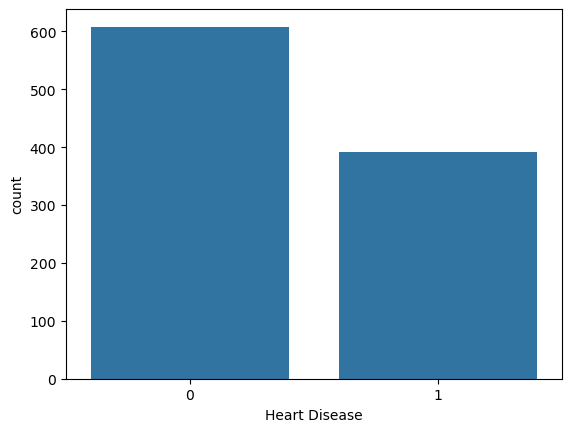

In [12]:
sns.countplot(x='Heart Disease', data=df)

Text(0.5, 1.0, 'Heart Disease Frequency')

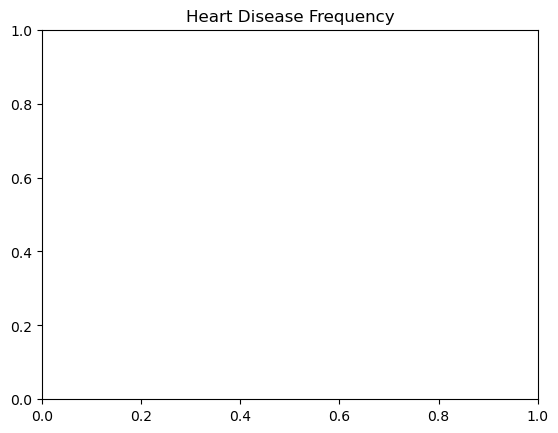

In [13]:
plt.title("Heart Disease Frequency")

<Axes: xlabel='Heart Disease', ylabel='Age'>

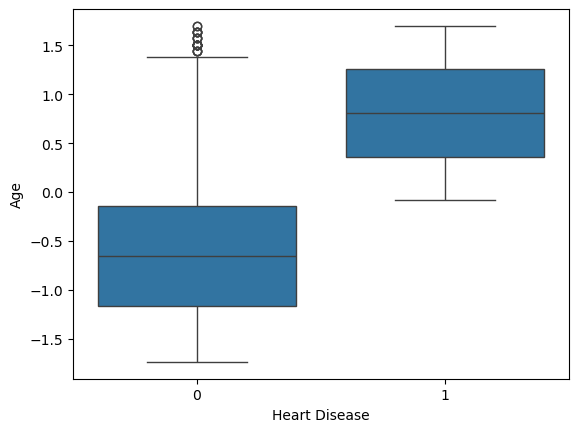

In [14]:
sns.boxplot(x='Heart Disease', y='Age', data=df)

In [15]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Axes: >

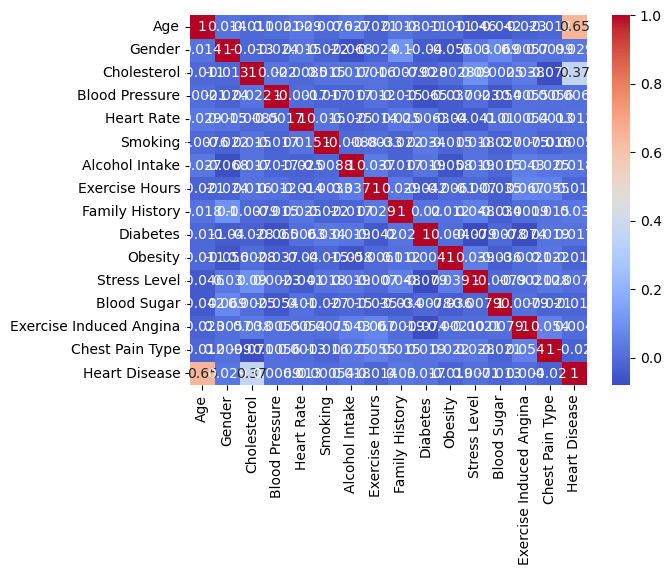

In [16]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

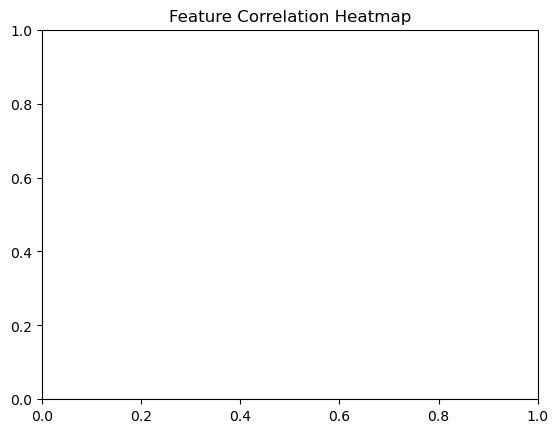

In [20]:
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
df['Risk_Index'] = (df['Cholesterol'] + df['Blood Pressure'] + df['Stress Level']) / 3


In [22]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC()
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Naive Bayes trained successfully.
SVM trained successfully.



Logistic Regression Performance:
Accuracy: 0.86
Precision: 0.8375
Recall: 0.8170731707317073
F1 Score: 0.8271604938271605


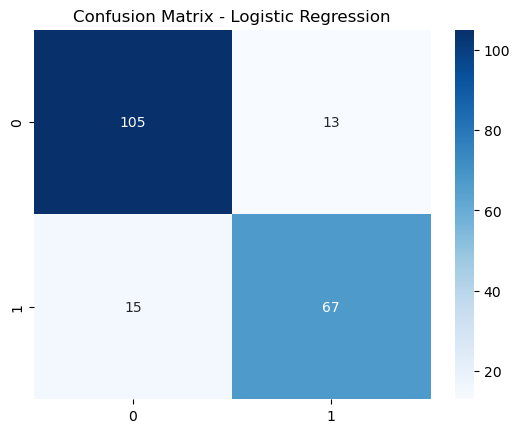


Decision Tree Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


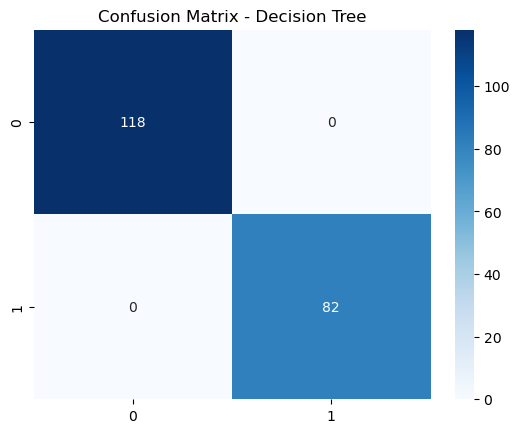


Random Forest Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


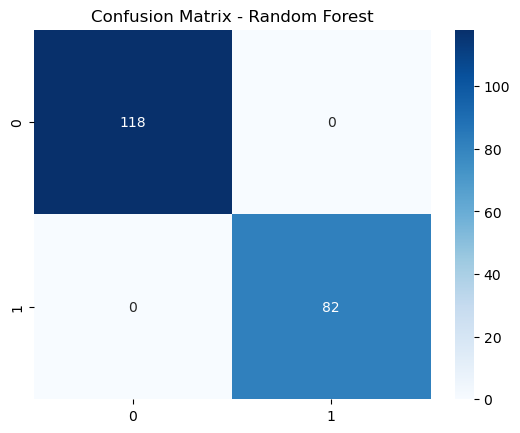


Naive Bayes Performance:
Accuracy: 0.92
Precision: 0.9583333333333334
Recall: 0.8414634146341463
F1 Score: 0.8961038961038961


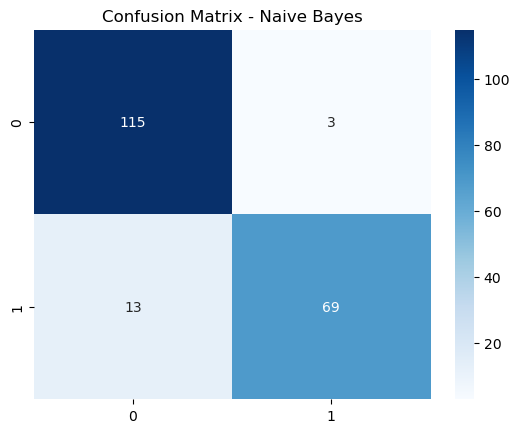


SVM Performance:
Accuracy: 0.915
Precision: 0.922077922077922
Recall: 0.8658536585365854
F1 Score: 0.8930817610062893


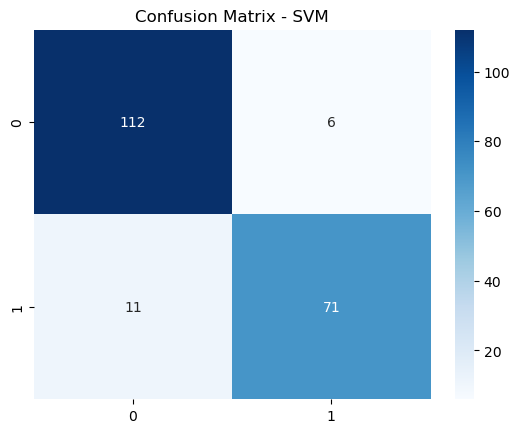

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

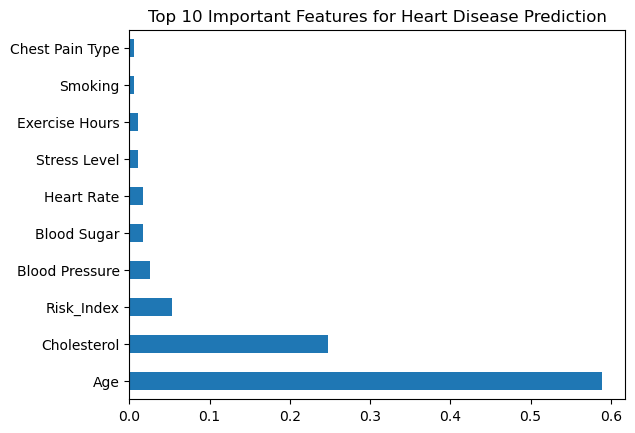

In [28]:
# Feature importance for Random Forest (if applicable)
model = models['Random Forest']
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features for Heart Disease Prediction')
plt.show()


In [29]:
prob = models['Random Forest'].predict_proba(X_test)[:,1]
df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Risk_Score': prob})
df_results.head()


,Actual,Predicted,Risk_Score
521,1,1,0.96
737,0,0,0.00
740,0,0,0.04
660,0,0,0.00
411,1,1,0.92
